# 06 - Stochastic Volatility (extension)

Addresses the innovation-diagnostics limitation from notebook 05: the
constant-variance Gaussian DLM leaves **volatility clustering** and **fat tails**
in the residuals. Here the observation variance is given its **own stochastic
process** and estimated by **MCMC** (PyMC).

**Two-step approach.** The time-varying coefficients $\theta_t$ are taken from the
Gaussian DLM (notebook 04); a stochastic-volatility model is fitted to its
one-step-ahead forecast errors $e_t$. This keeps the coefficient paths (the risk
reactions) and only replaces the constant error variance by a time-varying one:

$$
e_t \sim N\!\big(0,\; e^{h_t}\big), \qquad
h_t = h_{t-1} + \eta_t, \quad \eta_t \sim N(0,\sigma_\eta^2)
$$

so the standard deviation at $t$ is $e^{h_t/2}$ and $h_t=\log V_t$ is a log-variance
random walk. Estimated with PyMC/NUTS (non-centered parameterization).

> **Runtime.** MCMC over the full daily sample takes a few minutes. For a quick
> first pass, lower `DRAWS`/`TUNE` or set `N_OBS` to a smaller number.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats

import safe_haven as sh
from safe_haven import FIG_DIR

CURRENCY = "JPY"     # which currency to model
LAMBDA   = 1e-3      # DLM smoothness prior (as in notebook 04)
DRAWS, TUNE, CHAINS = 1000, 1000, 4
N_OBS = None         # None = full sample; e.g. 1500 for a quick run

# nutpie (Rust NUTS sampler) is 2-4x faster than PyMC's Python sampler and much
# lighter on memory -- both matter on a fanless MacBook Air. Falls back cleanly.
try:
    import nutpie  # noqa: F401
    NUTS_KWARGS = {"nuts_sampler": "nutpie"}
except ImportError:
    NUTS_KWARGS = {}
    print("nutpie not installed (pip install nutpie) -> PyMC's default sampler")

nutpie not installed (pip install nutpie) -> PyMC's default sampler


## Residuals from the Gaussian DLM

Refit the DLM (notebook 04) and take its one-step-ahead forecast errors $e_t$.

In [2]:
data = sh.load_data()
df = data.model_frame(CURRENCY)
res, ols = sh.dlm_fit(df, LAMBDA)

e = pd.Series(res.forecasts_error[0], index=df.index).replace([np.inf, -np.inf], np.nan).dropna()
if N_OBS:
    e = e.iloc[-N_OBS:]
print(f"{CURRENCY}: {len(e)} residuals")

JPY: 5286 residuals


## Diagnostics before

Kurtosis and Jarque-Bera on the raw residuals (normal kurtosis = 3).

In [3]:
print(f"kurtosis     = {stats.kurtosis(e, fisher=False):.2f}")
print(f"Jarque-Bera p = {stats.jarque_bera(e)[1]:.2g}")

kurtosis     = 9.54
Jarque-Bera p = 0


## Stochastic-volatility model (PyMC)

Log-variance random walk, non-centered. `pm.sample` runs NUTS.

In [4]:
y = e.values
n = len(y)
with pm.Model() as sv:
    sigma_eta = pm.HalfNormal("sigma_eta", 0.3)          # sd of log-variance innovations
    h0 = pm.Normal("h0", np.log(np.var(y)), 2.0)         # initial log-variance
    z = pm.Normal("z", 0, 1, shape=n)                    # standardized innovations (non-centered)
    h = pm.Deterministic("h", h0 + sigma_eta * pm.math.cumsum(z))
    pm.Normal("obs", 0.0, pm.math.exp(h / 2), observed=y)
    idata = pm.sample(DRAWS, tune=TUNE, chains=CHAINS, cores=min(CHAINS, os.cpu_count() or 1),
                      target_accept=0.95, random_seed=1, progressbar=True,
                      **NUTS_KWARGS)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_eta, h0, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 227 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


## Convergence

In [5]:
az.summary(idata, var_names=["sigma_eta", "h0"], round_to=3)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_eta,0.143,0.012,0.124,0.163,613.447,1149.290,1.004,0.000,0.00
h0,-10.748,0.497,-11.513,-9.927,1303.634,1758.184,1.002,0.014,0.01


## Estimated volatility path

Posterior standard deviation $e^{h_t/2}$ over time, with an 80% credible band.

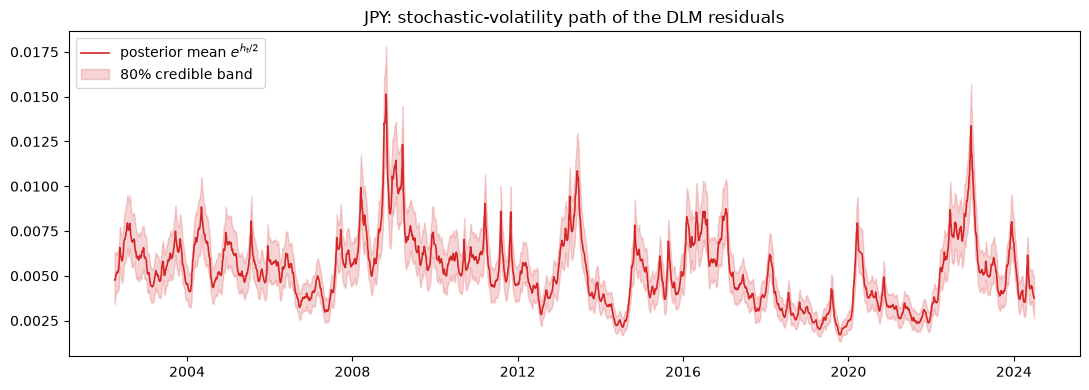

In [6]:
h_draws = idata.posterior["h"].stack(s=("chain", "draw")).transpose("s", "h_dim_0").values
sd_draws = np.exp(h_draws / 2)
sd_mean = sd_draws.mean(0)
lo, hi = np.percentile(sd_draws, [10, 90], axis=0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(e.index, sd_mean, color="C3", lw=1.2, label="posterior mean $e^{h_t/2}$")
ax.fill_between(e.index, lo, hi, color="C3", alpha=0.2, label="80% credible band")
ax.set_title(f"{CURRENCY}: stochastic-volatility path of the DLM residuals")
ax.legend()
fig.tight_layout()
FIG_DIR.mkdir(exist_ok=True)
fig.savefig(FIG_DIR / f"sv_{CURRENCY}.png", dpi=300, bbox_inches="tight")
plt.show()

## Diagnostics after

Standardize the residuals by the estimated volatility, $z_t = e_t / e^{h_t/2}$,
and re-check kurtosis and normality.

In [7]:
z_std = e.values / sd_mean
print(f"kurtosis      = {stats.kurtosis(z_std, fisher=False):.2f}   (was {stats.kurtosis(e, fisher=False):.2f})")
print(f"Jarque-Bera p = {stats.jarque_bera(z_std)[1]:.2g}   (was {stats.jarque_bera(e)[1]:.2g})")

kurtosis      = 3.57   (was 9.54)
Jarque-Bera p = 2.5e-16   (was 0)
